In [1]:
import mcmr

/home/azma/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
geom = mcmr.Geometry(
    x_world=50, y_world=50,
    default_material="Pb",
    default_source=0,
    bc_top="reflective",
    bc_bot="vacuum",
    bc_left="reflective",
    bc_right="vacuum",
)

geom.add_region(3, 3, 47, 47, material="Fe")
for i in range(7, 47, 8):
    geom.fill_col(i, i+4, material="C", source=1)
for i in range(7, 47, 8):
    geom.fill_row(i, i+4, material="Fe", source=0)
    
geom.add_circle(x=25, y=25, r=10, material="C", source=1)
geom.add_circle(x=10, y=40, r=5, material="Fe", source=2)

In [3]:
world = geom.build()

In [4]:
sim = world.run(N=10000)

              MCMR Simulation Engine               
 Total Particle   : 10000
running...
Progress: [10000/10000] (100%)
 Simulation End in 8.0019 seconds.



In [5]:
t = sim.get_tally()
print(t.absorp_by_material)

{'C': 3388, 'Fe': 5694, 'Pb': 108}


In [6]:
world.export("mcmr_world.xml")

'mcmr_world.xml'

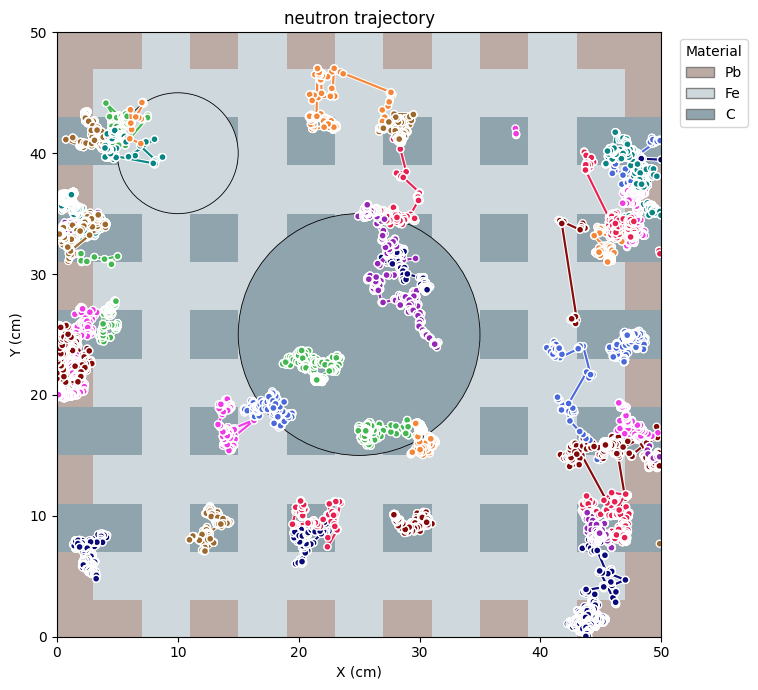

In [7]:
plotter = mcmr.ResultsPlotter("mcmr_results.xml")
plotter.plot_trajectories(world_xml="mcmr_world.xml")